<a href="https://colab.research.google.com/github/ckesmay/portfolio/blob/main/machinelearningfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [269]:
import pandas as pd
import numpy as np

In [270]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

df = pd.read_csv (r'/content/gdrive/MyDrive/Colab Notebooks/df_arabica_clean.csv')

Mounted at /content/gdrive


This data was obtained by scraping https://database.coffeeinstitute.org/coffees/arabica using selenium. I was inspired by a dataset that I found on [kaggle](https://www.kaggle.com/datasets/fatihb/coffee-quality-data-cqi) which was a few years old. I made some alterations to the code used to scrape the coffee institute website, so it worked on the up-to-date site.

In [271]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             207 non-null    int64  
 1   ID                     207 non-null    int64  
 2   Country of Origin      207 non-null    object 
 3   Farm Name              205 non-null    object 
 4   Lot Number             206 non-null    object 
 5   Mill                   204 non-null    object 
 6   ICO Number             75 non-null     object 
 7   Company                207 non-null    object 
 8   Altitude               206 non-null    object 
 9   Region                 205 non-null    object 
 10  Producer               206 non-null    object 
 11  Number of Bags         207 non-null    int64  
 12  Bag Weight             207 non-null    object 
 13  In-Country Partner     207 non-null    object 
 14  Harvest Year           207 non-null    object 
 15  Gradin

**Sensory evaluations (coffee quality scores)**

*   Aroma: Refers to the scent or fragrance of the coffee.
*   Flavor: The flavor of coffee is evaluated based on the taste, including any sweetness, bitterness, acidity, and other flavor notes.
*   Aftertaste: Refers to the lingering taste that remains in the mouth after swallowing the coffee.
*   Acidity: Acidity in coffee refers to the brightness or liveliness of the taste.
*   Body: The body of coffee refers to the thickness or viscosity of the coffee in the mouth.
*   Uniformity: Uniformity refers to the consistency of the coffee from cup to cup.
*   Clean Cup: A clean cup refers to a coffee that is free of any off-flavors or defects, such as sourness, mustiness, or staleness.
*  Sweetness: It can be described as caramel-like, fruity, or floral, and is a desirable quality in coffee.
*   Balance: Balance refers to how well the different flavor components of the coffee work together.

**Defects**

Defects are undesirable qualities that can occur in coffee beans during processing or storage. Defects can be categorized into two categories: Category One and Category Two defects.

Category One defects are primary defects that can be perceived through visual inspection of the coffee beans. These defects include: Black beans, sour beans, insect-damaged beans, fungus-damaged beans etc.

Category Two defects are secondary defects that are more subtle and can only be detected through tasting. These defects include: Over-fermentation, staleness, rancidness, chemical taste etc.


In [272]:
df = df.drop(['Farm Name', 'Lot Number', 'Mill','ICO Number','Company','Producer','Number of Bags','Bag Weight','In-Country Partner',
         'Harvest Year','Grading Date','Owner','Status','Quakers','Expiration','Certification Body','Certification Address',
         'Certification Contact','Clean Cup','Sweetness','Defects','Uniformity', 'Overall'],axis=1)

I dropped all of the columns that will be irrelevant to the analysis. Some of the values above that seem relevent (e.g. Sweetness, Uniformity) were dropped because all coffees were given the same value.

In [273]:
df['Altitude'] = df['Altitude'].astype(str).str.extract(r'(\d{4})')
df['Altitude'] = df['Altitude'].astype(float).astype('Int64')

In [274]:
# Rename the column 'Total Cup Points' to 'Overall Quality'
df.rename(columns={'Total Cup Points': 'Overall Quality'}, inplace=True)

# Show confirmation
df.columns


Index(['Unnamed: 0', 'ID', 'Country of Origin', 'Altitude', 'Region',
       'Variety', 'Processing Method', 'Aroma', 'Flavor', 'Aftertaste',
       'Acidity', 'Body', 'Balance', 'Overall Quality', 'Moisture Percentage',
       'Category One Defects', 'Color', 'Category Two Defects'],
      dtype='object')

Changing the variable type of altitude and only showing the lower bound if it is a range.

In [275]:
df.describe()

,Unnamed: 0,ID,Altitude,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Overall Quality,Moisture Percentage,Category One Defects,Category Two Defects
count,207.000000,207.000000,160.0,207.000000,207.000000,207.000000,207.00000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000
mean,103.000000,103.000000,1525.81875,7.721063,7.744734,7.599758,7.69029,7.640918,7.644058,83.706570,10.735266,0.135266,2.251208
std,59.899917,59.899917,616.550914,0.287626,0.279613,0.275911,0.25951,0.233499,0.256299,1.730417,1.247468,0.592070,2.950183
min,0.000000,0.000000,1000.0,6.500000,6.750000,6.670000,6.83000,6.830000,6.670000,78.000000,0.000000,0.000000,0.000000
25%,51.500000,51.500000,1200.0,7.580000,7.580000,7.420000,7.50000,7.500000,7.500000,82.580000,10.100000,0.000000,0.000000
50%,103.000000,103.000000,1395.0,7.670000,7.750000,7.580000,7.67000,7.670000,7.670000,83.750000,10.800000,0.000000,1.000000
75%,154.500000,154.500000,1600.0,7.920000,7.920000,7.750000,7.87500,7.750000,7.790000,84.830000,11.500000,0.000000,3.000000
max,206.000000,206.000000,5400.0,8.580000,8.500000,8.420000,8.58000,8.250000,8.420000,89.330000,13.500000,5.000000,16.000000


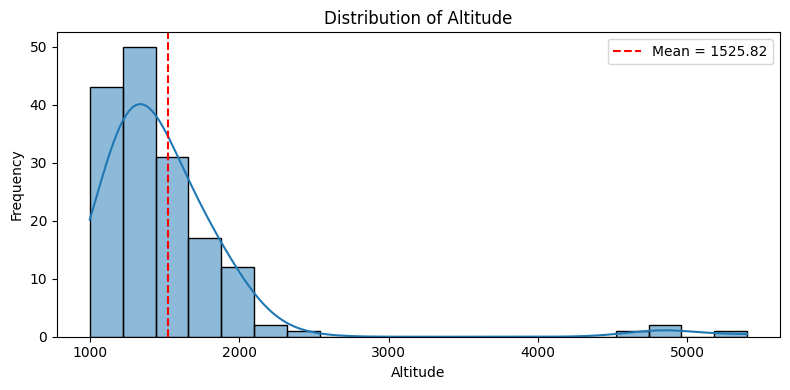

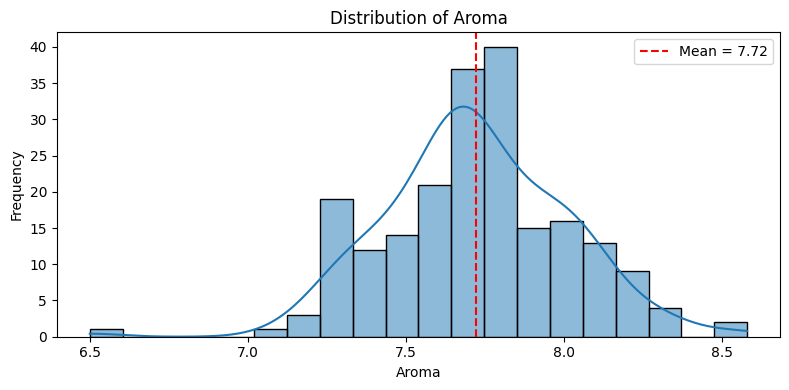

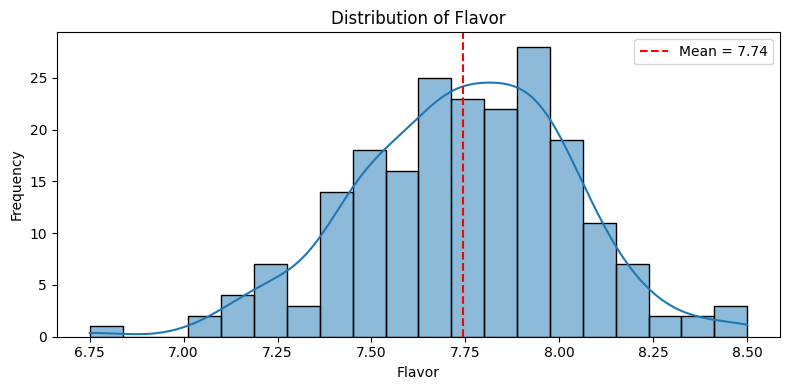

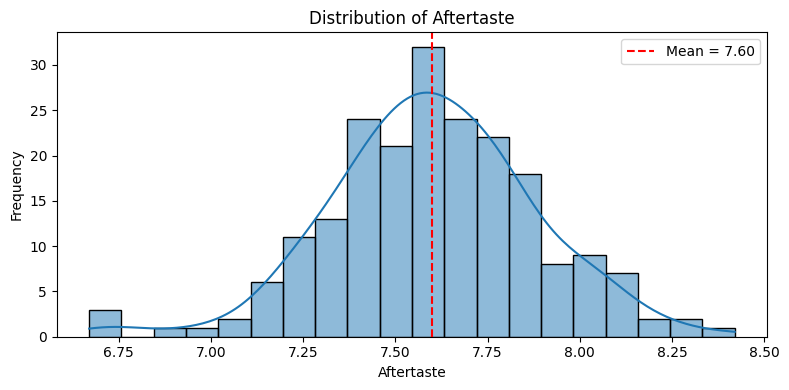

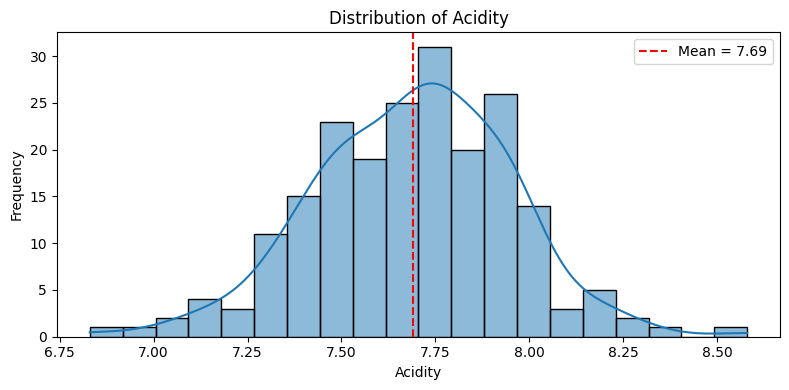

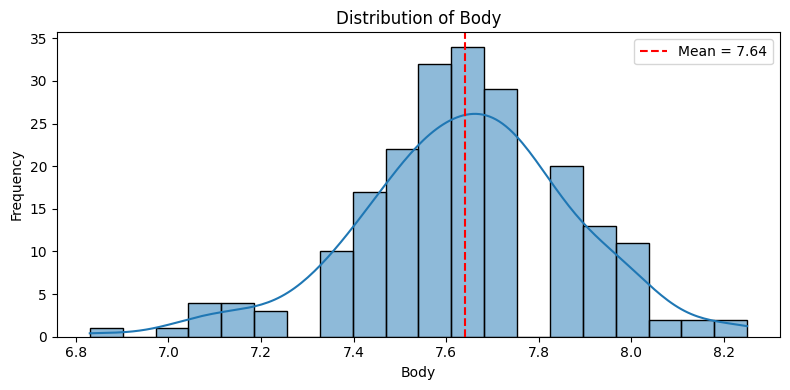

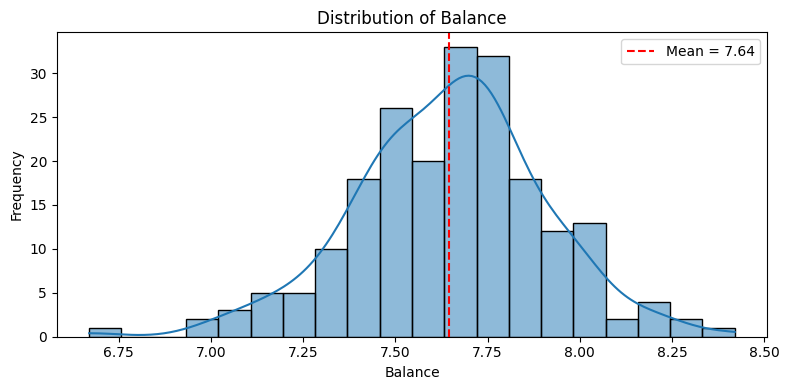

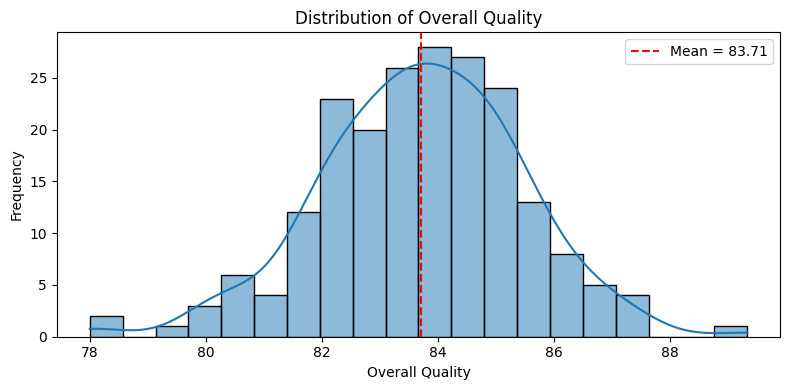

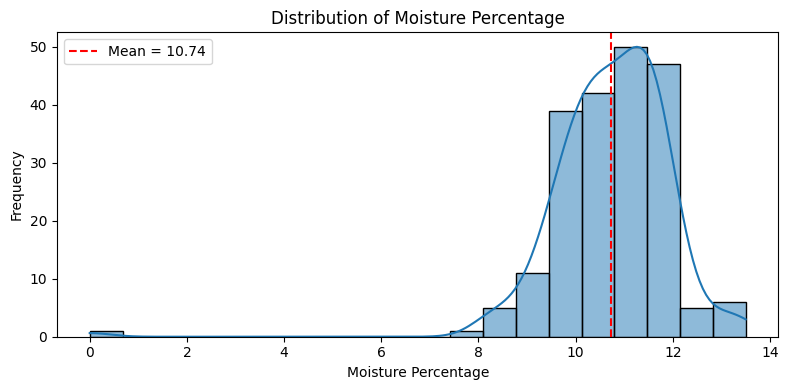

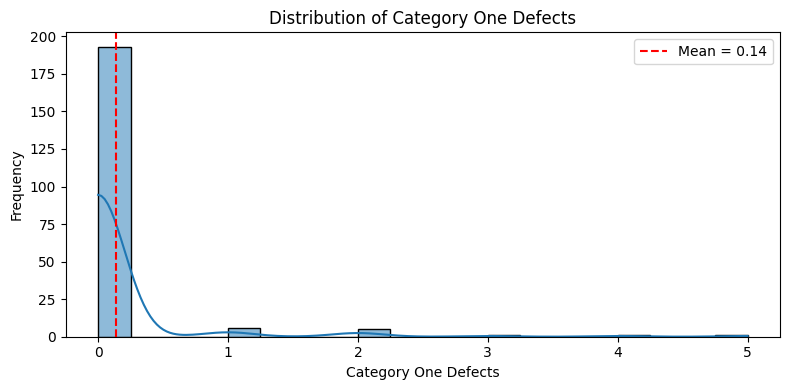

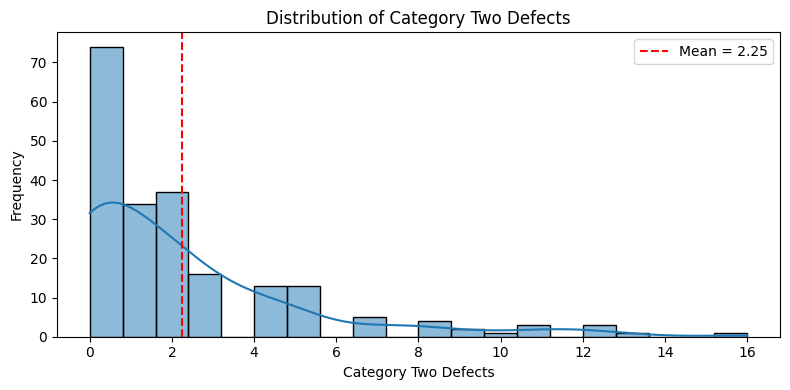

In [276]:
import seaborn as sns
# Ensure 'numeric_cols' is updated or re-calculated based on current df columns
numeric_cols = df.select_dtypes(include=['float64', 'Int64']).columns
numeric_cols_filtered = [col for col in numeric_cols if col not in ['Unnamed: 0', 'ID']]


# Create subplots showing distribution and mean line for each numeric feature
for col in numeric_cols_filtered:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), bins=20, kde=True)
    plt.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean = {df[col].mean():.2f}')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

In [277]:
# Replace 'Tanzania, United Republic Of' with 'Tanzania'
df['Country of Origin'] = df['Country of Origin'].replace({
    'Tanzania, United Republic Of': 'Tanzania'
})

df['Country of Origin'] = df['Country of Origin'].replace({
    'United States (Hawaii)': 'Hawaii'
})

# Confirm the changes
df['Country of Origin'].unique()


array(['Colombia', 'Taiwan', 'Laos', 'Costa Rica', 'Guatemala',
       'Tanzania', 'Ethiopia', 'Thailand', 'Brazil', 'Hawaii', 'Kenya',
       'Uganda', 'Indonesia', 'Peru', 'Panama', 'Nicaragua', 'Vietnam',
       'Honduras', 'El Salvador', 'Madagascar', 'Mexico', 'Myanmar'],
      dtype=object)

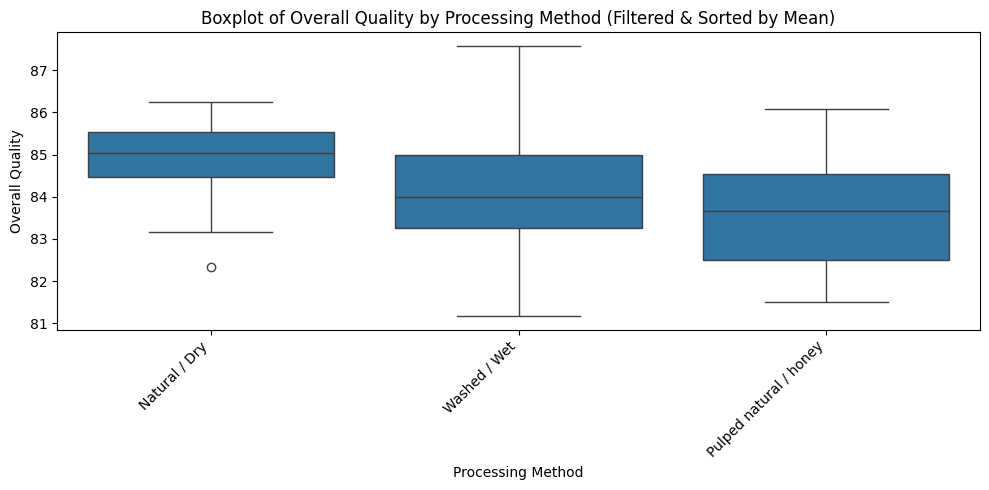

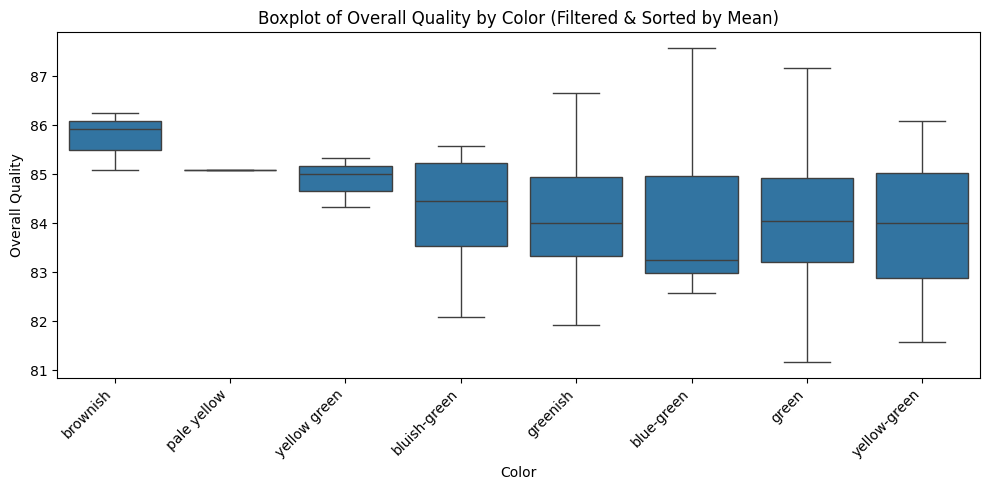

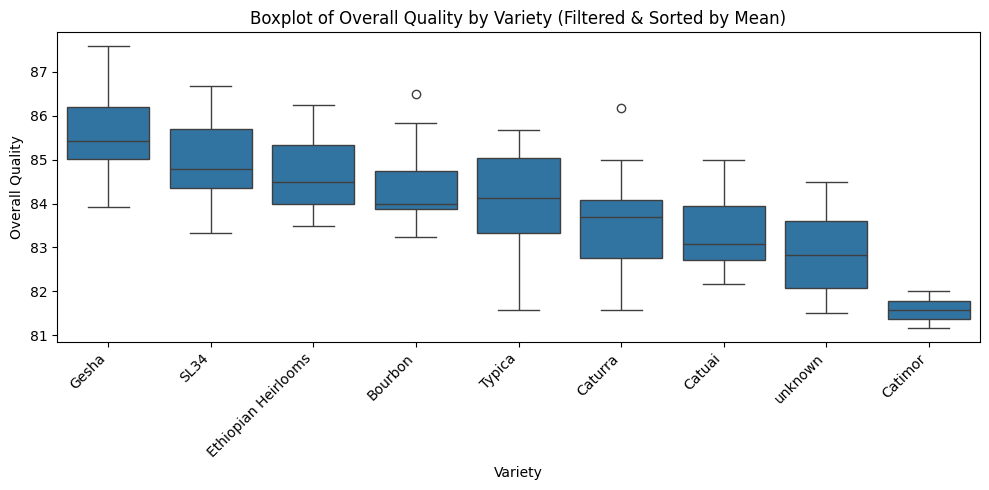

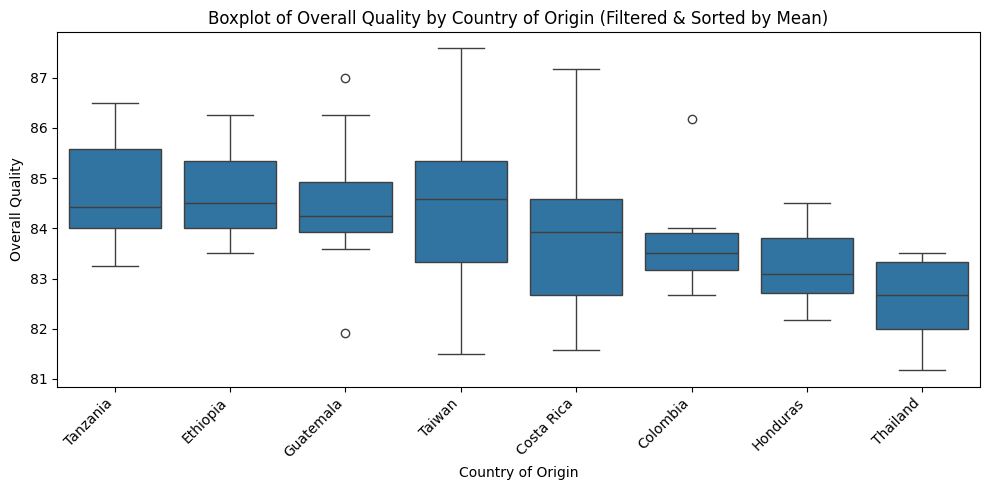

In [265]:
# Set threshold for minimum category frequency
min_samples = 5

# Filter out low-frequency categories
for col in ['Processing Method', 'Color', 'Variety', 'Country of Origin']:
    counts = df[col].value_counts()
    valid_categories = counts[counts >= min_samples].index
    df = df[df[col].isin(valid_categories)]

# Plot boxplots sorted by mean overall quality (descending)
for col in ['Processing Method', 'Color', 'Variety', 'Country of Origin']:
    # Compute mean overall quality per category and sort
    order = df.groupby(col)['Overall Quality'].mean().sort_values(ascending=False).index
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=col, y='Overall Quality', order=order)
    plt.title(f'Boxplot of Overall Quality by {col} (Filtered & Sorted by Mean)')
    plt.xlabel(col)
    plt.ylabel('Overall Quality')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


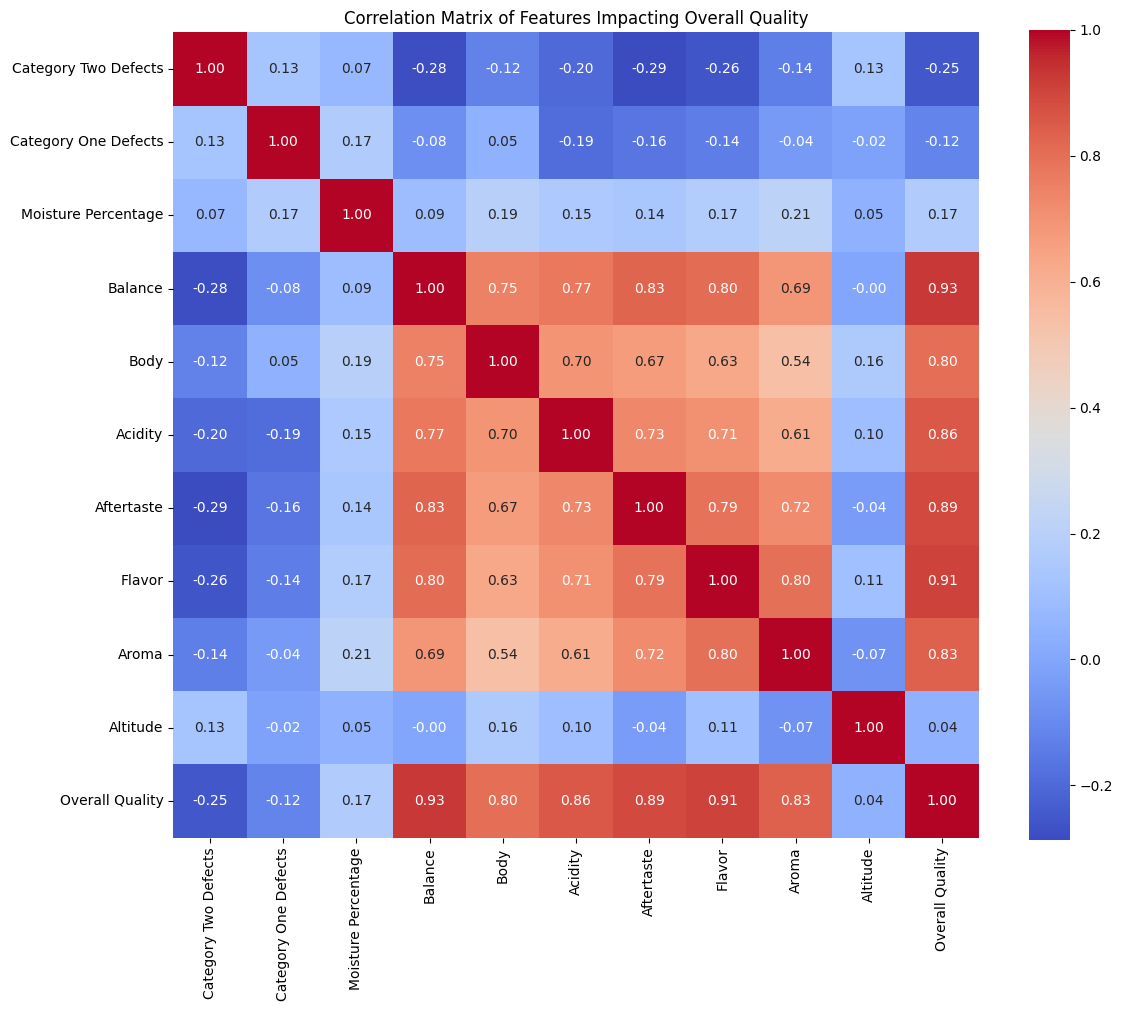

In [266]:
# Select relevant numeric features including the target
correlation_features = [
    'Category Two Defects', 'Category One Defects', 'Moisture Percentage', 'Balance', 'Body', 'Acidity',
    'Aftertaste', 'Flavor', 'Aroma', 'Altitude', 'Overall Quality'
]

# Compute the correlation matrix
correlation_matrix = df[correlation_features].corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Matrix of Features Impacting Overall Quality')
plt.tight_layout()
plt.show()


Strong Positive Correlates with Overall Quality
These features have the highest positive correlation with Overall Quality, suggesting they're most influential:

Balance (r = 0.93)

Flavor (r = 0.91)

Aftertaste (r = 0.89)

Acidity (r = 0.86)

Aroma (r = 0.83)

Body (r = 0.80)


# **Model 1: Multiple Linear Regression (OLS)**

In [279]:
# Creating dummy variables for the categorical variables
df_dummies = pd.get_dummies(df)
df_dummies.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Columns: 225 entries, Unnamed: 0 to Color_yellowish
dtypes: Int64(1), bool(212), float64(8), int64(4)
memory usage: 64.2 KB


In [295]:
df_model = df_dummies.drop(columns=['Unnamed: 0', 'ID'])
df_model.head()
df_model_clean = df_model.dropna()
df_model_clean.head(10)


,Altitude,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Overall Quality,Moisture Percentage,Category One Defects,...,Color_browish-green,Color_brownish,Color_green,Color_greenish,Color_pale yellow,Color_yello-green,Color_yellow green,Color_yellow- green,Color_yellow-green,Color_yellowish
0,1700,8.58,8.50,8.42,8.58,8.25,8.42,89.33,11.8,0,...,False,False,True,False,False,False,False,False,False,False
1,1200,8.50,8.50,7.92,8.00,7.92,8.25,87.58,10.5,0,...,False,False,False,False,False,False,False,False,False,False
2,1300,8.33,8.42,8.08,8.17,7.92,8.17,87.42,10.4,0,...,False,False,False,False,False,False,False,False,False,True
3,1900,8.08,8.17,8.17,8.25,8.17,8.08,87.17,11.8,0,...,False,False,True,False,False,False,False,False,False,False
4,1850,8.33,8.33,8.08,8.25,7.92,7.92,87.08,11.6,0,...,False,False,False,False,False,False,False,False,True,False
5,1668,8.33,8.33,8.25,7.83,7.83,8.17,87.00,10.7,0,...,False,False,True,False,False,False,False,False,False,False
6,1250,8.33,8.17,8.08,8.00,7.83,8.25,86.92,9.1,0,...,False,False,True,False,False,False,False,False,False,False
7,1200,8.25,8.25,8.17,8.00,7.92,8.08,86.75,10.0,0,...,False,False,False,False,False,False,True,False,False,False
8,1250,8.08,8.08,8.25,8.08,7.92,8.00,86.67,10.8,0,...,False,False,False,True,False,False,False,False,False,False
9,1400,8.08,8.17,8.08,8.17,8.00,8.00,86.50,11.0,0,...,False,False,False,True,False,False,False,False,False,False


# Model 1: OLS Linear Regression

In [306]:
import numpy as np

# Calculate correlation matrix
corr_matrix = X.corr().abs()

# Select upper triangle of correlation matrix (to avoid duplicate pairs)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > 0.9
high_corr_features = [column for column in upper.columns if any(upper[column] > 0.95)]

# Drop these features
X_reduced = X.drop(columns=high_corr_features)

# (Optional) Print dropped features
print("Dropped due to high collinearity:", high_corr_features)


Dropped due to high collinearity: ['Region_Boquete', 'Region_Itasy', 'Region_South Shan State', 'Variety_BOURBON, CATURRA Y CATIMOR', 'Variety_Bourbon Sidra', 'Variety_Castillo', 'Variety_Castillo,Caturra,Bourbon', 'Variety_Catimor,Catuai,Caturra,Bourbon', 'Variety_Catucai', 'Variety_Caturra-Catuai', 'Variety_Jember,TIM-TIM,Ateng', 'Variety_Lempira', 'Variety_MARSELLESA, CATUAI, CATURRA & MARSELLESA, ANACAFE 14, CATUAI', 'Variety_Maragogype', 'Variety_Red Bourbon', 'Variety_SL14', 'Variety_SL28,SL34,Ruiru11', 'Variety_Santander', 'Variety_Typica Bourbon Caturra Catimor', 'Variety_Wolishalo,Kurume,Dega', 'Variety_Yellow Catuai', 'Variety_unknown', 'Processing Method_Anaerobico 1000h', 'Processing Method_Double Anaerobic Washed', 'Processing Method_Double Carbonic Maceration / Natural', 'Processing Method_Honey,Mossto', 'Processing Method_SEMI-LAVADO', 'Processing Method_Semi Washed', 'Processing Method_Wet Hulling']


In [307]:
# Re-include sensory variables by starting from original df_dummies

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.api as sm

X = X_reduced
X = df_model_clean.drop(columns=['Overall Quality'])
y = df_model_clean['Overall Quality']


# Convert all columns to float
X = X.astype(float)
y = y.astype(float)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Add constant for intercept
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse_reg = mean_squared_error(y_test, y_pred)
r2_reg = r2_score(y_test, y_pred)


# Make sure to add a constant to capture the intercept
X_with_const = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X_with_const).fit()

print(model.summary())
'''

X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)

# Fit OLS model
ols_model = sm.OLS(y_train, X_train_ols).fit()


# Predict and evaluate
y_pred_ols = ols_model.predict(X_test_ols)
mse_ols = mean_squared_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)
print(ols_model.summary())
print("OLS Performance:")
print(f"Mean Squared Error: {mse_ols:.2f}")
print(f"R² Score: {r2_ols:.2f}")
'''


                            OLS Regression Results                            
Dep. Variable:        Overall Quality   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     178.9
Date:                Fri, 02 May 2025   Prob (F-statistic):           5.54e-16
Time:                        20:19:57   Log-Likelihood:                 267.01
No. Observations:                 160   AIC:                            -246.0
Df Residuals:                      16   BIC:                             196.8
Df Model:                         143                                         
Covariance Type:            nonrobust                                         
                                                                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

'\n\nX_train_ols = sm.add_constant(X_train)\nX_test_ols = sm.add_constant(X_test)\n\n# Fit OLS model\nols_model = sm.OLS(y_train, X_train_ols).fit()\n\n\n# Predict and evaluate\ny_pred_ols = ols_model.predict(X_test_ols)\nmse_ols = mean_squared_error(y_test, y_pred_ols)\nr2_ols = r2_score(y_test, y_pred_ols)\nprint(ols_model.summary())\nprint("OLS Performance:")\nprint(f"Mean Squared Error: {mse_ols:.2f}")\nprint(f"R² Score: {r2_ols:.2f}")\n'

With an R-sqared of 0.503, approximately 50% of the variability in overall quality is explained by the predictors in the model

In [308]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate performance
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

mse_rf, r2_rf


(0.11213525562500141, 0.9555422782816033)

                   Feature  Importance
2                   Flavor    0.364753
3               Aftertaste    0.262653
6                  Balance    0.239186
4                  Acidity    0.075520
1                    Aroma    0.018028
5                     Body    0.013037
0                 Altitude    0.004745
9     Category Two Defects    0.002974
7      Moisture Percentage    0.002071
108  Region_Piendamo,Cauca    0.001492


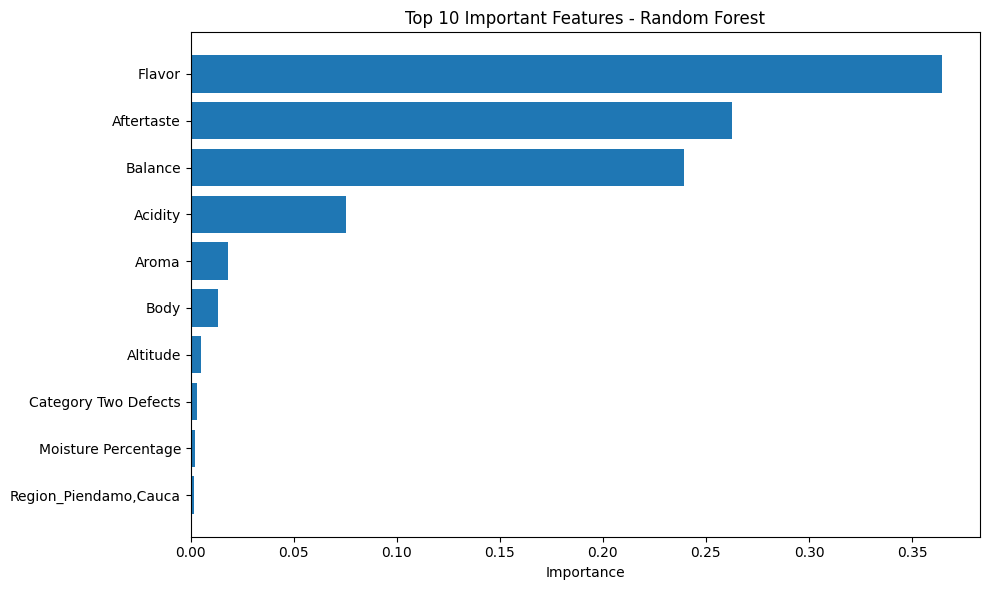

In [309]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances and create a DataFrame
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
feature_importances.sort_values(by='Importance', ascending=False, inplace=True)

# Display top 20 features
print(feature_importances.head(10))

# Plot top 20 features
plt.figure(figsize=(10, 6))
plt.barh(feature_importances.head(10)['Feature'], feature_importances.head(10)['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Important Features - Random Forest")
plt.tight_layout()
plt.show()
